In [ ]:
# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense


In [ ]:
# 2. LOAD DATASET
df = pd.read_csv("Electric_Vehicle_Population_Data (Nov 27 ).csv")
df.head()

In [ ]:
# 3. CLEAN COLUMN NAMES
df.columns = df.columns.str.strip()

print("Columns in dataset:")
print(df.columns)

In [ ]:
# 4. SELECT IMPORTANT FEATURES
selected_columns = ["Electric Range", "Base MSRP"]   # <-- change this list as needed
df = df[selected_columns]
df = df.dropna()

In [ ]:
# 5. NORMALIZE DATA
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df)

In [ ]:
# 6. CREATE SEQUENCES
def create_sequences(data, time_steps=10):
    X = []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
    return np.array(X)

TIME_STEPS = 10
X = create_sequences(data_scaled, TIME_STEPS)

print("Shape of data:", X.shape)

In [ ]:
# 7. TRAIN-TEST SPLIT
train_size = int(0.8 * len(X))

X_train = X[:train_size]
X_test = X[train_size:]

In [ ]:
# 8. BUILD LSTM AUTOENCODER
inputs = Input(shape=(TIME_STEPS, X.shape[2]))

# Encoder
encoded = LSTM(64, activation='relu', return_sequences=False)(inputs)
encoded = RepeatVector(TIME_STEPS)(encoded)

# Decoder
decoded = LSTM(64, activation='relu', return_sequences=True)(encoded)
decoded = TimeDistributed(Dense(X.shape[2]))(decoded)

model = Model(inputs, decoded)
model.compile(optimizer='adam', loss='mse')

model.summary()

In [ ]:
# ===============================
# 9. TRAIN MODEL
# ===============================
history = model.fit(
    X_train, X_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    shuffle=True
)

In [ ]:
# ===============================
# 10. RECONSTRUCTION ERROR
# ===============================
X_pred = model.predict(X_test)

mse = np.mean(np.power(X_test - X_pred, 2), axis=(1,2))

In [ ]:
# ===============================
# 11. SET THRESHOLD
# ===============================
threshold = np.mean(mse) + 3*np.std(mse)

# Detect anomalies
anomalies = mse > threshold

print("Threshold:", threshold)
print("Total anomalies detected:", np.sum(anomalies))

Columns in dataset:
Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='str')
Shape of data: (269659, 10, 2)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 2)          │           130 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,306 (196.51 KB)

 Trainable params: 50,306 (196.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
6068/6068 ━━━━━━━━━━━━━━━━━━━━ 91s 14ms/step - loss: 0.0094 - val_loss: 0.0039
Epoch 2/10
6068/6068 ━━━━━━━━━━━━━━━━━━━━ 82s 13ms/step - loss: 0.0026 - val_loss: 0.0016
Epoch 3/10
6068/6068 ━━━━━━━━━━━━━━━━━━━━ 82s 13ms/step - loss: 0.0012 - val_loss: 9.2437e-04
Epoch 4/10
6068/6068 ━━━━━━━━━━━━━━━━━━━━ 279s 46ms/step - loss: 6.3144e-04 - val_loss: 4.2566e-04
Epoch 5/10
6068/6068 ━━━━━━━━━━━━━━━━━━━━ 89s 15ms/step - loss: 3.4857e-04 - val_loss: 2.4463e-04
Epoch 6/10
6068/6068 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 2.2829e-04 - val_loss: 1.6331e-04
Epoch 7/10
6068/6068 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 1.4694e-04 - val_loss: 1.6238e-04
Epoch 8/10
6068/6068 ━━━━━━━━━━━━━━━━━━━━ 96s 16ms/step - loss: 1.0821e-04 - val_loss: 8.0791e-05
Epoch 9/10
6068/6068 ━━━━━━━━━━━━━━━━━━━━ 101s 17ms/step - loss: 9.0704e-05 - val_loss: 7.0768e-05
Epoch 10/10
6068/6068 ━━━━━━━━━━━━━━━━━━━━ 99s 16ms/step - loss: 7.7757e-05 - val_loss: 6.8763e-05
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 14s 8m

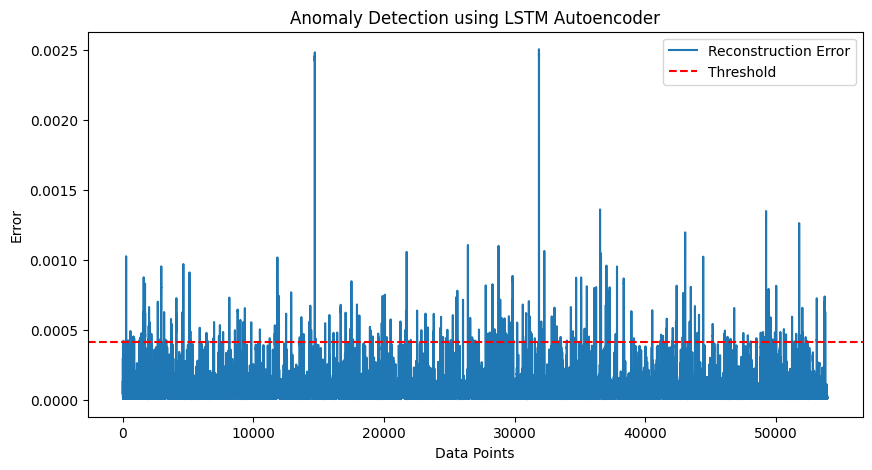

In [ ]:
# ===============================
# 12. PLOT RESULT
# ===============================
plt.figure(figsize=(10,5))
plt.plot(mse, label='Reconstruction Error')
plt.axhline(threshold, color='r', linestyle='--', label='Threshold')
plt.title("Anomaly Detection using LSTM Autoencoder")
plt.xlabel("Data Points")
plt.ylabel("Error")
plt.legend()
plt.show()

In [11]:
loss_table = pd.DataFrame({
    'Epoch': range(1, 11),
    'Train Loss': history.history['loss'],
    'Validation Loss': history.history['val_loss']
})
print("\nAUTOENCODER TRAINING LOSS PROGRESSION")
display(loss_table.set_index('Epoch'))


AUTOENCODER TRAINING LOSS PROGRESSION


,Train Loss,Validation Loss
Epoch,,
1,0.009441,0.003860
2,0.002609,0.001567
3,0.001184,0.000924
4,0.000631,0.000426
5,0.000349,0.000245
6,0.000228,0.000163
7,0.000147,0.000162
8,0.000108,0.000081
9,0.000091,0.000071


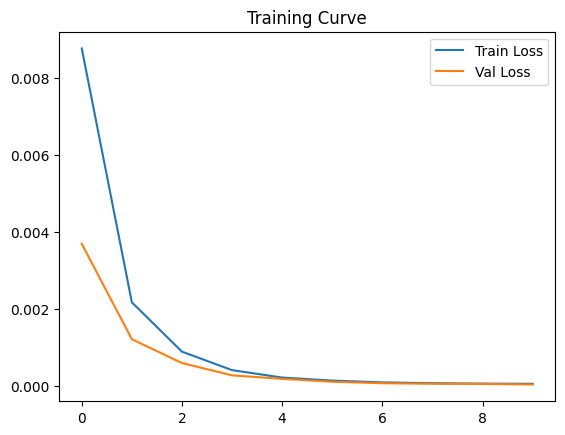

In [24]:
plt.figure()    
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Training Curve")
plt.show()

In [ ]:
# MODEL EVALUATION (Reconstruction Loss)
# ===============================
test_loss = model.evaluate(X_test, X_test)

print("Test Reconstruction Loss (MSE):", test_loss)

1686/1686 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 4.1042e-05
Test Reconstruction Loss (MSE): 4.104165782337077e-05


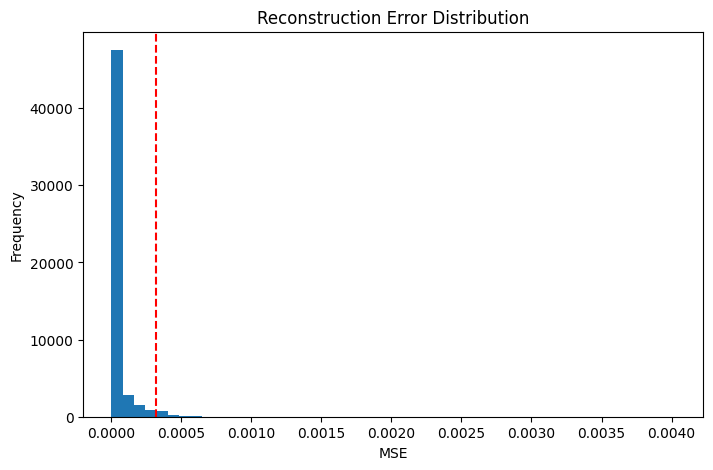

In [ ]:
# ERROR DISTRIBUTION
# ===============================
plt.figure(figsize=(8,5))
plt.hist(mse, bins=50)
plt.axvline(threshold, color='r', linestyle='--')
plt.title("Reconstruction Error Distribution")
plt.xlabel("MSE")
plt.ylabel("Frequency")
plt.show()

Confusion Matrix:
 [[51235     0]
 [ 1500  1197]]


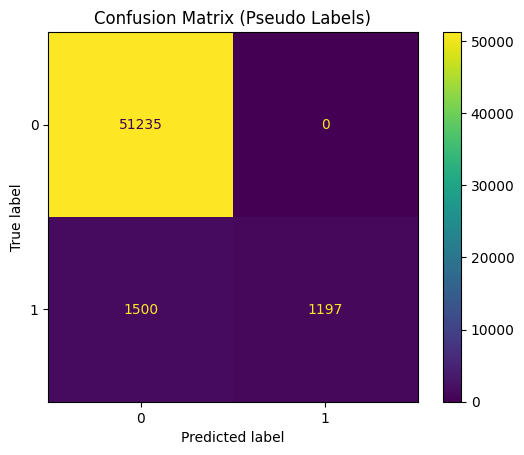

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create fake ground truth (top 5% as anomalies)
y_true = (mse > np.percentile(mse, 95)).astype(int)

# Model predictions
y_pred = anomalies.astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (Pseudo Labels)")
plt.show()

In [12]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = anomalies.astype(int)

# Pseudo labels (same as before)
y_true = (mse > np.percentile(mse, 95)).astype(int)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

# Full report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


Accuracy: 0.9686827857301787

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     51236
           1       1.00      0.37      0.54      2696

    accuracy                           0.97     53932
   macro avg       0.98      0.69      0.76     53932
weighted avg       0.97      0.97      0.96     53932

